# BSGAL Notebook


## 1. Setup


In [1]:
# Runtime: "colab" or "local".
RUNTIME = "colab"

# Install dependencies
import sys, subprocess
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "lvis", "pycocotools", "opencv-python-headless", "tqdm"],
    check=False,
)

# Mount Google Drive (Colab only)
if RUNTIME == "colab":
    try:
        import os
        from google.colab import drive
        if not os.path.exists("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        else:
            print("[OK] Drive already mounted.")
    except ImportError:
        print("[INFO] Not running in Colab — skipping Drive mount.")

import sys, torch, torchvision
print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"CUDA avail:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:         {p.name}  ({p.total_memory / 1e9:.1f} GB)")
else:
    print("[WARN] No GPU detected — training akan sangat lambat di CPU.")


[INFO] Not running in Colab — skipping Drive mount.
Python:      3.12.13
PyTorch:     2.11.0+cu128
TorchVision: 0.26.0+cu128
CUDA avail:  True
GPU:         NVIDIA GeForce RTX 4090  (25.3 GB)


## 2. Imports


In [2]:
import os, json, math, random, copy, time, types, warnings
from dataclasses import dataclass, field
from collections import deque, defaultdict, Counter
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Any

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import roi_heads as tv_roi_heads

from pycocotools import mask as mask_utils

# NumPy compatibility: add back np.float for lvis library (removed in NumPy 1.20+)
if not hasattr(np, 'float'):
    np.float = float

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_float32_matmul_precision("high")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")


DEVICE: cuda


## 3. Config


In [3]:
@dataclass
class Config:
    # ─── Paths ───────────────────────────────────────────
    @staticmethod
    def _discover_base_dir() -> str:
        # 1) explicit override
        env_base = os.environ.get("BSGAL_BASE_DIR")
        if env_base:
            p = Path(env_base).expanduser().resolve()
            if (p / "datasets" / "metadata" / "lvis_v1_train_cat_info.json").exists():
                return str(p)

        # 2) auto-discovery for notebook/script usage
        cwd = Path.cwd().resolve()
        script_dir = Path(__file__).resolve().parent if "__file__" in globals() else cwd
        candidates = [
            cwd,
            cwd.parent,
            script_dir,
            Path("/workspace/BSGAL-KELOMPOK-4"),
            Path("/content/drive/MyDrive/DiverGen/BSGAL-KELOMPOK-4"),
            Path("/home/fzhnf/Public/studyRepos/DiverGen/BSGAL-KELOMPOK-4"),  # legacy local path
        ]
        for p in candidates:
            if (p / "datasets" / "metadata" / "lvis_v1_train_cat_info.json").exists():
                return str(p)

        # 3) safe fallback
        return str(cwd)

    BASE_DIR: str = field(default_factory=_discover_base_dir)

    # ─── Scale & Schedule ───────────────────────────────
    BASELINE_EPOCHS: int = 1
    BSGAL_EPOCHS: int = 1
    BASELINE_ITERS: Optional[int] = None  # if set, overrides EPOCHS
    BSGAL_ITERS: Optional[int] = None
    TRAIN_SUBSET_SIZE: Optional[int] = 600  # None = full LVIS train
    VAL_SUBSET_SIZE: Optional[int] = 100    # None = full val
    IMS_PER_BATCH: int = 8
    ACTIVE_TEST_BATCHSIZE: int = 4
    IMAGE_SIZE: int = 640
    NUM_WORKERS: int = 2

    # ─── Logging & Checkpoint ───────────────────────────
    LOG_EVERY: int = 10
    EVAL_EVERY_EPOCH: int = 1     # Evaluate after each epoch
    CKPT_EVERY_EPOCH: int = 1     # Save checkpoint after each epoch

    # ─── Optimizer ──────────────────────────────────────
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    WARMUP_ITERS: int = 50
    BSGAL_WARMUP_ITERS: int = 25  # shorter for fine-tune phase
    CLIP_GRAD_NORM: float = 1.0
    USE_AMP: bool = True

    # ─── Federated Loss ─────────────────────────────────
    USE_FED_LOSS: bool = True
    FED_LOSS_NUM_CAT: int = 50
    FED_LOSS_FREQ_WEIGHT: float = 0.5

    # ─── Copy-Paste ─────────────────────────────────────
    INST_POOL_MAX_SAMPLES: int = 10
    MASK_THRESHOLD: int = 127
    BBOX_OCCLUDED_THR: int = 10
    MASK_OCCLUDED_THR: int = 300
    SCALE_MIN_FRAC: float = 10.0 / 640.0
    SCALE_MAX_FRAC: float = 0.5
    SHAPE_JITTER: float = 0.2

    # ─── BSGAL Active Learning ──────────────────────────
    BSGAL_ENABLED: bool = True
    ACTIVE_GRAD_MOMENTUM: float = 0.1
    ACTIVE_DECISION_BIAS: float = -0.05  # add to sim_ori; reference 'paste_only_-0.05'

    # ─── Misc ───────────────────────────────────────────
    NUM_CLASSES: int = 1203  # LVIS v1, no background
    SEED: int = 42
    SKIP_IF_EXISTS: bool = True
    TINY: bool = False  # toggle smoke test (override below)

    # ─── Derived (path properties) ──────────────────────
    @property
    def DATASETS_DIR(self): return f"{self.BASE_DIR}/datasets"
    @property
    def MODELS_DIR(self): return f"{self.BASE_DIR}/models"
    @property
    def TRAIN_IMG_DIR(self): return f"{self.DATASETS_DIR}/lvis/train2017"
    @property
    def VAL_IMG_DIR(self): return f"{self.DATASETS_DIR}/lvis/val2017"
    @property
    def TRAIN_ANN_JSON(self): return f"{self.DATASETS_DIR}/lvis/lvis_v1_train.json"
    @property
    def VAL_ANN_JSON(self): return f"{self.DATASETS_DIR}/lvis/lvis_v1_val.json"
    @property
    def INST_POOL_JSON(self): return f"{self.DATASETS_DIR}/instance/output/LVIS_instance_pools.json"
    @property
    def INST_POOL_ROOT(self): return f"{self.DATASETS_DIR}/instance"
    @property
    def AREA_STATS_JSON(self): return f"{self.DATASETS_DIR}/metadata/area_mean_std2.json"
    @property
    def CAT_INFO_JSON(self): return f"{self.DATASETS_DIR}/metadata/lvis_v1_train_cat_info.json"
    @property
    def BASELINE_CKPT_DIR(self): return f"{self.MODELS_DIR}/pretrained-model"
    @property
    def BSGAL_CKPT_DIR(self): return f"{self.MODELS_DIR}/model"


cfg = Config()

# Smoke test switch.
# cfg.TINY = True
if cfg.TINY:
    cfg.BASELINE_EPOCHS = 1
    cfg.BSGAL_EPOCHS = 1
    cfg.TRAIN_SUBSET_SIZE = 64
    cfg.VAL_SUBSET_SIZE = 8
    cfg.IMS_PER_BATCH = 2
    cfg.ACTIVE_TEST_BATCHSIZE = 2
    cfg.LOG_EVERY = 5

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.SEED)

Path(cfg.BASELINE_CKPT_DIR).mkdir(parents=True, exist_ok=True)
Path(cfg.BSGAL_CKPT_DIR).mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR: {cfg.BASE_DIR}")
print(f"TINY:     {cfg.TINY}")
print(f"BASELINE: {cfg.BASELINE_EPOCHS} epoch | TRAIN_SUBSET: {cfg.TRAIN_SUBSET_SIZE} | BATCH: {cfg.IMS_PER_BATCH}")
print(f"BSGAL:    {cfg.BSGAL_EPOCHS} epoch | TEST_BATCH: {cfg.ACTIVE_TEST_BATCHSIZE}")
print(f"DEVICE:   {DEVICE}")


BASE_DIR: /workspace/BSGAL-KELOMPOK-4
TINY:     False
BASELINE: 1 epoch | TRAIN_SUBSET: 600 | BATCH: 8
BSGAL:    1 epoch | TEST_BATCH: 4
DEVICE:   cuda


## 4. Utils


In [4]:
def to_device(obj, device):
    """Recursively move tensors in nested dict/list/tuple to device."""
    if isinstance(obj, torch.Tensor):
        return obj.to(device, non_blocking=True)
    if isinstance(obj, dict):
        return {k: to_device(v, device) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        out = [to_device(v, device) for v in obj]
        return type(obj)(out) if not isinstance(obj, list) else out
    return obj


def cosine_warmup_lr(step: int, base_lr: float, warmup: int, total: int) -> float:
    """Linear warmup then cosine decay to 0."""
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    progress = min(1.0, max(0.0, progress))
    return 0.5 * base_lr * (1.0 + math.cos(math.pi * progress))


def set_lr(optimizer, lr: float):
    for g in optimizer.param_groups:
        g["lr"] = lr


class MetricLogger:
    """Smoothed metric averaging over a deque window."""
    def __init__(self, window: int = 50):
        self.data = defaultdict(lambda: deque(maxlen=window))

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if v is None:
                continue
            if isinstance(v, torch.Tensor):
                v = v.item()
            self.data[k].append(float(v))

    def avg(self, key: str) -> float:
        d = self.data[key]
        return sum(d) / len(d) if d else 0.0

    def fmt(self, keys: Optional[List[str]] = None) -> str:
        keys = keys or list(self.data.keys())
        return " | ".join(f"{k}={self.avg(k):.4f}" for k in keys if self.data[k])


## 5. LVIS Loader


In [5]:
def load_cat_info(path: str, num_classes: int = 1203, freq_weight_pow: float = 0.5):
    """Load lvis_v1_train_cat_info.json → frequency weights and metadata.

    Returns dict:
        cat_freq_weight  Tensor[num_classes] = image_count^freq_weight_pow (contig)
        cat_freq_class   {contig_id -> 'r'/'c'/'f'}
        cat_names        list[str] of length num_classes (contig order)
    """
    with open(path) as f:
        items = json.load(f)
    items_sorted = sorted(items, key=lambda x: x["id"])
    assert len(items_sorted) == num_classes, (
        f"expected {num_classes} cats, got {len(items_sorted)}"
    )
    image_counts = np.array([c["image_count"] for c in items_sorted], dtype=np.float32)
    cat_freq_weight = torch.from_numpy(image_counts ** freq_weight_pow)
    cat_freq_class = {i: items_sorted[i]["frequency"] for i in range(num_classes)}
    cat_names = [items_sorted[i]["name"] for i in range(num_classes)]
    return {
        "cat_freq_weight": cat_freq_weight,
        "cat_freq_class": cat_freq_class,
        "cat_names": cat_names,
    }


def load_lvis_to_records(
    json_path: str,
    image_dir: str,
    subset_size: Optional[int] = None,
    seed: int = 42,
    require_annotations: bool = True,
) -> List[dict]:
    """Parse LVIS JSON → list of records.

    Each record: {file_name, image_id, height, width, annotations,
                  neg_category_ids_contig, not_exhaustive_category_ids_contig}.
    Each annotation: {bbox_xywh, category_id_contig, segmentation, iscrowd}.
    """
    print(f"[LVIS] loading {json_path} ...")
    with open(json_path) as f:
        lvis = json.load(f)

    img_index = {img["id"]: img for img in lvis["images"]}

    anns_by_img: Dict[int, list] = defaultdict(list)
    skipped = 0
    for ann in lvis["annotations"]:
        # Drop polygons with <6 points (less than a triangle).
        valid_segs = [seg for seg in ann.get("segmentation", []) if len(seg) >= 6]
        if not valid_segs:
            skipped += 1
            continue
        anns_by_img[ann["image_id"]].append({
            "bbox_xywh": ann["bbox"],
            "category_id_contig": ann["category_id"] - 1,  # 1..1203 → 0..1202
            "segmentation": valid_segs,
            "iscrowd": ann.get("iscrowd", 0),
        })

    def _derive_fname(img: dict) -> str:
        # Derive filename from file_name/coco_url.
        if "file_name" in img:
            fn = img["file_name"]
        elif "coco_url" in img:
            fn = img["coco_url"]
        else:
            # Fallback from image id.
            fn = f"{int(img['id']):012d}.jpg"
        return fn.split("/")[-1]

    records = []
    for img_id, img in img_index.items():
        anns = anns_by_img.get(img_id, [])
        if require_annotations and len(anns) == 0:
            continue
        fname = _derive_fname(img)
        full_path = os.path.join(image_dir, fname)
        # Skip missing image files.
        if not os.path.exists(full_path):
            continue
        records.append({
            "file_name": full_path,
            "image_id": img_id,
            "height": img["height"],
            "width": img["width"],
            "annotations": anns,
            "neg_category_ids_contig": [c - 1 for c in img.get("neg_category_ids", [])],
            "not_exhaustive_category_ids_contig": [c - 1 for c in img.get("not_exhaustive_category_ids", [])],
        })
    print(f"[LVIS] {len(records)} images with annotations ({skipped} bad polygons skipped)")

    if subset_size is not None and subset_size < len(records):
        rng = random.Random(seed)
        rng.shuffle(records)
        records = records[:subset_size]
        print(f"[LVIS] subset to {len(records)} records (seed={seed})")
    return records


# Quick smoke output.
cat_info = load_cat_info(cfg.CAT_INFO_JSON)
print(f"cat_names[0:3]:    {cat_info['cat_names'][:3]}")
print(f"freq_weight shape: {tuple(cat_info['cat_freq_weight'].shape)}")
print(f"r/c/f counts:      {Counter(cat_info['cat_freq_class'].values())}")


cat_names[0:3]:    ['aerosol_can', 'air_conditioner', 'airplane']
freq_weight shape: (1203,)
r/c/f counts:      Counter({'c': 461, 'f': 405, 'r': 337})


## 6. Augment


In [6]:
def polygons_to_bitmask(polygons: List[list], h: int, w: int) -> np.ndarray:
    """COCO polygon list → uint8 bitmask [H, W] (0/1)."""
    if not polygons:
        return np.zeros((h, w), dtype=np.uint8)
    rles = mask_utils.frPyObjects(polygons, h, w)
    rle = mask_utils.merge(rles) if isinstance(rles, list) else rles
    return mask_utils.decode(rle).astype(np.uint8)


def letterbox(image: np.ndarray, masks: Optional[np.ndarray], size: int,
              pad_value: int = 114) -> Tuple[np.ndarray, Optional[np.ndarray], float, Tuple[int, int]]:
    """Resize keeping aspect ratio, pad to square (size x size). Pad bottom-right.

    Returns (image, masks, scale, (pad_x, pad_y)) where pad is added size minus content.
    """
    h, w = image.shape[:2]
    scale = size / max(h, w)
    new_h, new_w = int(round(h * scale)), int(round(w * scale))
    image_r = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    out = np.full((size, size, image.shape[2]), pad_value, dtype=image.dtype)
    out[:new_h, :new_w] = image_r

    masks_out = None
    if masks is not None and len(masks) > 0:
        masks_r = np.stack([
            cv2.resize(m, (new_w, new_h), interpolation=cv2.INTER_NEAREST) for m in masks
        ], axis=0)
        masks_out = np.zeros((masks_r.shape[0], size, size), dtype=np.uint8)
        masks_out[:, :new_h, :new_w] = masks_r
    elif masks is not None:
        masks_out = np.zeros((0, size, size), dtype=np.uint8)
    return out, masks_out, scale, (size - new_w, size - new_h)


def random_hflip(image: np.ndarray, masks: np.ndarray, p: float = 0.5
                 ) -> Tuple[np.ndarray, np.ndarray]:
    if random.random() < p:
        image = image[:, ::-1].copy()
        if masks is not None and len(masks) > 0:
            masks = masks[:, :, ::-1].copy()
    return image, masks


def bboxes_from_masks(masks: np.ndarray) -> np.ndarray:
    """[N, H, W] uint8 → [N, 4] xyxy (float32). Empty mask → [0, 0, 0, 0]."""
    if len(masks) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    boxes = np.zeros((len(masks), 4), dtype=np.float32)
    for i, m in enumerate(masks):
        ys, xs = np.where(m > 0)
        if len(xs) == 0:
            continue
        boxes[i] = [xs.min(), ys.min(), xs.max() + 1, ys.max() + 1]
    return boxes


def get_largest_connected_component(mask: np.ndarray) -> np.ndarray:
    """Keep only the largest connected component of a binary mask."""
    if mask.sum() == 0:
        return mask
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask.astype(np.uint8), connectivity=8)
    if n <= 1:
        return mask
    # stats[0] is background; pick the largest of 1..n-1
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = 1 + int(np.argmax(areas))
    return (labels == largest).astype(np.uint8)


## 7. Instance Pool


In [7]:
class InstancePool:
    """Manages synthetic RGBA instances for copy-paste augmentation."""

    def __init__(
        self,
        pool_json: str,
        root_dir: str,
        area_stats_json: str,
        scale_min_frac: float,
        scale_max_frac: float,
        mask_threshold: int,
        shape_jitter: float,
        max_samples: int,
    ):
        self.root_dir = root_dir
        self.scale_min_frac = scale_min_frac
        self.scale_max_frac = scale_max_frac
        self.mask_threshold = mask_threshold
        self.shape_jitter = shape_jitter
        self.max_samples = max_samples

        # Load instance pool.
        with open(pool_json) as f:
            raw = json.load(f)
        self.per_cat_pool: Dict[int, List[str]] = {}
        for k, v in raw.items():
            cid = int(k)
            paths = []
            for p in v:
                clean = p[1:] if p.startswith("*") else p
                paths.append(os.path.join(root_dir, clean))
            self.per_cat_pool[cid] = paths
        self.cats_with_pool = [c for c, paths in self.per_cat_pool.items() if len(paths) > 0]

        # Load area stats.
        with open(area_stats_json) as f:
            raw_area = json.load(f)
        self.area_stats: Dict[int, Tuple[float, float]] = {}
        for k, v in raw_area.items():
            cid = int(k) - 1
            self.area_stats[cid] = (float(v[0]), float(v[1]))
        assert min(self.area_stats) == 0 and max(self.area_stats) == 1202, (
            "area_stats must cover contig 0..1202 after key conversion"
        )

        print(f"[InstPool] {len(self.cats_with_pool)} cats with pool, "
              f"avg {sum(len(v) for v in self.per_cat_pool.values()) / max(1, len(self.per_cat_pool)):.1f} insts/cat")

    def sample_cats(self, k: int) -> List[int]:
        """Class-uniform random sampling (cas_random)."""
        return [random.choice(self.cats_with_pool) for _ in range(k)]

    def load_rgba_instance(self, cat_contig: int, base_h: int, base_w: int) -> Optional[dict]:
        """Sample one instance for cat_contig, scale to area sampled from area_stats.

        Returns None on failure. On success returns dict with:
            rgba: HxWx4 uint8
            mask: HxW uint8 (binary)
            label_contig: int
        """
        paths = self.per_cat_pool.get(cat_contig, [])
        if not paths:
            return None
        path = random.choice(paths)
        try:
            img = np.array(Image.open(path).convert("RGBA"))
        except Exception:
            return None
        if img.shape[0] < 4 or img.shape[1] < 4:
            return None

        # Sample area fraction.
        a_mean, a_std = self.area_stats.get(cat_contig, (0.05, 0.05))
        a_std = max(a_std, 1e-3)
        area_frac = float(np.clip(a_mean + np.random.randn() * a_std,
                                   self.scale_min_frac, self.scale_max_frac))
        area_pixels = area_frac * base_h * base_w
        if area_pixels < 16:
            return None

        # Sample aspect ratio.
        h_src, w_src = img.shape[:2]
        ratio = (w_src / h_src) * np.random.uniform(1 - self.shape_jitter, 1 + self.shape_jitter)
        target_w = math.sqrt(ratio * area_pixels)
        target_h = target_w / max(1e-3, ratio)
        target_w, target_h = max(2, int(round(target_w))), max(2, int(round(target_h)))

        if target_w >= base_w or target_h >= base_h:
            scale = min((base_w - 1) / target_w, (base_h - 1) / target_h) * 0.95
            target_w = max(2, int(target_w * scale))
            target_h = max(2, int(target_h * scale))

        img_r = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
        mask = (img_r[..., 3] >= self.mask_threshold).astype(np.uint8)
        if mask.sum() < 16:
            return None
        # Optional cleanup: largest CC.
        mask = get_largest_connected_component(mask)

        # Random hflip on the synthetic instance.
        if random.random() < 0.5:
            img_r = img_r[:, ::-1].copy()
            mask = mask[:, ::-1].copy()

        # Zero out RGB outside mask.
        img_r[..., 3] = mask * 255
        return {"rgba": img_r, "mask": mask, "label_contig": cat_contig}


def paste_instances_into(
    image: np.ndarray, masks: np.ndarray, labels: np.ndarray,
    instance_source: np.ndarray, src_instances: List[dict],
    bbox_occluded_thr: int, mask_occluded_thr: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """Paste each src instance into image (alpha blend), update masks with occlusion logic.

    Args:
        image: HxWx3 uint8.
        masks: NxHxW uint8 (existing instances).
        labels: [N] int (contig).
        instance_source: [N] uint8 (0=original LVIS, 1=pasted).
        src_instances: list of dicts from InstancePool.load_rgba_instance.

    Returns updated (image, masks, labels, instance_source).
    """
    H, W = image.shape[:2]
    image = image.copy()
    masks = masks.copy() if len(masks) else masks

    for src in src_instances:
        rgba = src["rgba"]
        smask = src["mask"]
        sh, sw = smask.shape
        if sh >= H or sw >= W:
            continue
        x = random.randint(0, W - sw - 1)
        y = random.randint(0, H - sh - 1)

        # Alpha blend.
        alpha = (smask.astype(np.float32))[..., None]  # HxWx1, 0/1
        roi = image[y:y+sh, x:x+sw].astype(np.float32)
        rgb = rgba[..., :3].astype(np.float32)
        blended = roi * (1 - alpha) + rgb * alpha
        image[y:y+sh, x:x+sw] = np.clip(blended, 0, 255).astype(np.uint8)

        # Build full-size paste mask.
        paste_mask = np.zeros((H, W), dtype=np.uint8)
        paste_mask[y:y+sh, x:x+sw] = smask

        # Update existing masks: subtract paste region (occlusion).
        if len(masks) > 0:
            new_masks = []
            new_labels = []
            new_source = []
            for i in range(len(masks)):
                m = masks[i]
                old_area = int(m.sum())
                old_box = _bbox_from_single(m)
                m2 = (m & (1 - paste_mask)).astype(np.uint8)
                new_area = int(m2.sum())
                if new_area < 16:
                    continue
                if old_area > 0:
                    bbox_shift = _bbox_shift(old_box, _bbox_from_single(m2))
                    if bbox_shift > bbox_occluded_thr and (old_area - new_area) > mask_occluded_thr:
                        # Visibly occluded → drop.
                        continue
                new_masks.append(m2)
                new_labels.append(labels[i])
                new_source.append(instance_source[i])
            masks = np.stack(new_masks, axis=0) if new_masks else np.zeros((0, H, W), np.uint8)
            labels = np.array(new_labels, dtype=np.int64) if new_labels else np.zeros((0,), np.int64)
            instance_source = np.array(new_source, dtype=np.uint8) if new_source else np.zeros((0,), np.uint8)

        # Append the pasted instance.
        masks = np.concatenate([masks, paste_mask[None]], axis=0) if len(masks) else paste_mask[None]
        labels = np.concatenate([labels, np.array([src["label_contig"]], dtype=np.int64)])
        instance_source = np.concatenate([instance_source, np.array([1], dtype=np.uint8)])

    return image, masks, labels, instance_source


def _bbox_from_single(m: np.ndarray) -> np.ndarray:
    ys, xs = np.where(m > 0)
    if len(xs) == 0:
        return np.zeros(4, dtype=np.float32)
    return np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1], dtype=np.float32)


def _bbox_shift(b1: np.ndarray, b2: np.ndarray) -> float:
    return float(np.max(np.abs(b1 - b2)))


## 8. Dataset


In [8]:
# Keep torchvision normalization path.

class LVISMaskDataset(Dataset):
    def __init__(self, records: List[dict], image_size: int):
        self.records = records
        self.image_size = image_size

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        rec = self.records[idx]
        # Suppress OpenCV warnings for missing files (shouldn't happen after LVIS filtering).
        import warnings
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            img_bgr = cv2.imread(rec["file_name"], cv2.IMREAD_COLOR)
        if img_bgr is None:
            # Missing image fallback (graceful degradation).
            img_bgr = np.zeros((rec["height"], rec["width"], 3), dtype=np.uint8)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        # Decode masks.
        anns = rec["annotations"]
        if anns:
            masks = np.stack([
                polygons_to_bitmask(a["segmentation"], h, w) for a in anns
            ], axis=0)
            labels = np.array([a["category_id_contig"] for a in anns], dtype=np.int64)
        else:
            masks = np.zeros((0, h, w), dtype=np.uint8)
            labels = np.zeros((0,), dtype=np.int64)

        # Letterbox to S×S, then random hflip.
        img_rgb, masks, _scale, _pad = letterbox(img_rgb, masks, self.image_size)
        img_rgb, masks = random_hflip(img_rgb, masks)
        instance_source = np.zeros((len(masks),), dtype=np.uint8)  # 0 = original

        return {
            "image_rgb_uint8": img_rgb,            # HxWx3 uint8 (after letterbox)
            "masks_uint8": masks,                  # NxHxW uint8
            "labels_contig": labels,               # [N] int64 (0..1202)
            "instance_source": instance_source,    # [N] uint8
            "image_id": rec["image_id"],
            "neg_category_ids_contig": rec.get("neg_category_ids_contig", []),
            "not_exhaustive_category_ids_contig": rec.get("not_exhaustive_category_ids_contig", []),
            "orig_size": (rec["height"], rec["width"]),
        }


## 9. Collator


In [9]:
def _to_torchvision_target(sample: dict) -> Tuple[torch.Tensor, dict]:
    """Convert sample dict → (image_tensor [3,H,W] float, target dict).

    Label shift: contig 0..1202 → torchvision 1..1203 (0=bg).
    """
    img = sample["image_rgb_uint8"]
    img_t = torch.from_numpy(img.transpose(2, 0, 1).copy()).float() / 255.0  # [3,H,W]

    masks = sample["masks_uint8"]
    labels_contig = sample["labels_contig"]

    if len(masks) > 0:
        boxes = bboxes_from_masks(masks)
        # Drop degenerate boxes.
        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        boxes = boxes[keep]
        masks = masks[keep]
        labels_contig = labels_contig[keep]
    else:
        boxes = np.zeros((0, 4), dtype=np.float32)

    # Shift labels to torchvision space.
    labels_tv = torch.from_numpy(labels_contig.astype(np.int64) + 1)
    boxes_t = torch.from_numpy(boxes.astype(np.float32))
    masks_t = torch.from_numpy(masks.astype(np.uint8))

    orig_h, orig_w = sample["orig_size"]
    target = {
        "boxes": boxes_t,
        "labels": labels_tv,
        "masks": masks_t,
        "image_id": torch.tensor([sample["image_id"]]),
        # Original (pre-letterbox) image size, needed at eval time to undo the
        # letterbox transform before submitting predictions to LVIS.
        "orig_size": torch.tensor([int(orig_h), int(orig_w)], dtype=torch.long),
    }
    return img_t, target


class CopyPasteCollator:
    """Collator that produces paste/ori/test triplet OR a single batch (baseline mode).

    Mode flags:
        triplet=True, paste_prob=1.0  → BSGAL training
        triplet=False, paste_prob=0.0 → baseline training (single ori batch)
        triplet=False, paste_prob=0.0 → eval (single batch)
    """

    def __init__(
        self,
        inst_pool: Optional[InstancePool],
        max_samples: int,
        triplet: bool,
        train_batch: int,
        test_batch: int,
        paste_prob: float = 1.0,
    ):
        self.inst_pool = inst_pool
        self.max_samples = max_samples
        self.triplet = triplet
        self.train_batch = train_batch
        self.test_batch = test_batch
        self.paste_prob = paste_prob

    def _paste_one(self, sample: dict) -> dict:
        if self.inst_pool is None or random.random() > self.paste_prob:
            return sample
        H, W = sample["image_rgb_uint8"].shape[:2]
        k = random.randint(1, max(1, self.max_samples))
        cats = self.inst_pool.sample_cats(k)
        src_insts = []
        for c in cats:
            inst = self.inst_pool.load_rgba_instance(c, H, W)
            if inst is not None:
                src_insts.append(inst)
        if not src_insts:
            return sample
        new_image, new_masks, new_labels, new_source = paste_instances_into(
            sample["image_rgb_uint8"],
            sample["masks_uint8"],
            sample["labels_contig"],
            sample["instance_source"],
            src_insts,
            bbox_occluded_thr=cfg.BBOX_OCCLUDED_THR,
            mask_occluded_thr=cfg.MASK_OCCLUDED_THR,
        )
        out = dict(sample)
        out["image_rgb_uint8"] = new_image
        out["masks_uint8"] = new_masks
        out["labels_contig"] = new_labels
        out["instance_source"] = new_source
        return out

    def __call__(self, samples: List[dict]):
        if self.triplet:
            train_samples = samples[:self.train_batch]
            test_samples = samples[self.train_batch:self.train_batch + self.test_batch]

            paste_pairs, ori_pairs, test_pairs = [], [], []
            for s in train_samples:
                paste_s = self._paste_one(copy.deepcopy(s))
                paste_pairs.append(_to_torchvision_target(paste_s))
                ori_pairs.append(_to_torchvision_target(s))
            for s in test_samples:
                test_pairs.append(_to_torchvision_target(s))

            return {
                "paste": paste_pairs,
                "ori": ori_pairs,
                "test": test_pairs,
            }
        else:
            # Single-batch mode.
            pairs = []
            for s in samples:
                if self.paste_prob > 0:
                    s = self._paste_one(copy.deepcopy(s))
                pairs.append(_to_torchvision_target(s))
            return pairs


## 10. Sampler


In [10]:
def compute_repeat_factors(records: List[dict], num_classes: int, threshold: float = 0.001) -> np.ndarray:
    """Compute per-image repeat factor for class-balanced sampling."""
    cat_image_count = np.zeros(num_classes, dtype=np.int64)
    for r in records:
        cats_in_img = {a["category_id_contig"] for a in r["annotations"]}
        for c in cats_in_img:
            cat_image_count[c] += 1
    total = len(records)
    freqs = cat_image_count / max(1, total)
    # Avoid div by zero for absent classes; r(c) for absent = 1.
    rc = np.where(freqs > 0, np.maximum(1.0, np.sqrt(threshold / np.maximum(freqs, 1e-9))), 1.0)

    image_rep = np.ones(len(records), dtype=np.float32)
    for i, r in enumerate(records):
        cats = {a["category_id_contig"] for a in r["annotations"]}
        if cats:
            image_rep[i] = max(rc[c] for c in cats)
    return image_rep


class RepeatFactorSampler(Sampler):
    """Yields an infinite stream of indices weighted by per-image repeat factors."""

    def __init__(self, repeat_factors: np.ndarray, seed: int = 42):
        self.repeat_factors = repeat_factors
        self.seed = seed

    def _epoch_indices(self, epoch: int) -> List[int]:
        rng = np.random.RandomState(self.seed + epoch)
        rf = self.repeat_factors
        # Stochastic rounding.
        rep_int = np.floor(rf).astype(np.int64) + (rng.rand(len(rf)) < (rf - np.floor(rf))).astype(np.int64)
        indices = []
        for i, r in enumerate(rep_int):
            indices.extend([i] * int(r))
        rng.shuffle(indices)
        return indices

    def __iter__(self):
        epoch = 0
        while True:
            for i in self._epoch_indices(epoch):
                yield i
            epoch += 1

    def __len__(self):
        # Informational length.
        return int(self.repeat_factors.sum())


## 11. Fed Loss


In [11]:
def get_fed_loss_inds(
    gt_classes_contig: torch.Tensor,
    num_sample_cats: int,
    num_classes_no_bg: int,
    freq_weight: torch.Tensor,
) -> torch.Tensor:
    """Return list of contig class indices to compute loss on this iter.

    Always includes all unique classes appearing in batch GT; samples extra
    weighted by freq_weight (no replacement) to reach num_sample_cats.
    """
    # GT contig ids.
    appeared = torch.unique(gt_classes_contig)
    appeared = appeared[appeared >= 0]  # safety
    appeared = appeared[appeared < num_classes_no_bg]

    if len(appeared) >= num_sample_cats:
        return appeared

    # Extra class samples.
    prob = freq_weight.to(appeared.device).clone()
    prob[appeared] = 0.0
    if prob.sum() <= 0:
        return appeared
    n_extra = num_sample_cats - len(appeared)
    n_extra = min(n_extra, int((prob > 0).sum().item()))
    if n_extra <= 0:
        return appeared
    extras = torch.multinomial(prob, n_extra, replacement=False)
    return torch.cat([appeared, extras], dim=0)


def federated_sigmoid_ce_loss(
    logits: torch.Tensor,
    labels_tv: torch.Tensor,
    freq_weight: torch.Tensor,
    num_sample_cats: int,
    num_classes_no_bg: int,
) -> torch.Tensor:
    """Sigmoid CE loss with federated category subsampling.

    Args:
        logits: [N, num_classes_no_bg+1]. Column 0 = background.
        labels_tv: [N], 0 = bg, 1..num_classes_no_bg = fg.
        freq_weight: [num_classes_no_bg] tensor on logits.device.
        num_sample_cats, num_classes_no_bg: ints.
    """
    N, C_total = logits.shape
    assert C_total == num_classes_no_bg + 1, f"got {C_total} expected {num_classes_no_bg + 1}"
    device = logits.device

    # One-hot target.
    target = torch.zeros_like(logits)
    fg_mask = labels_tv > 0
    if fg_mask.any():
        target[fg_mask, labels_tv[fg_mask]] = 1.0

    # Select fg classes.
    gt_contig = labels_tv[fg_mask] - 1 if fg_mask.any() else torch.empty(0, dtype=torch.long, device=device)
    inds_contig = get_fed_loss_inds(gt_contig, num_sample_cats, num_classes_no_bg, freq_weight)
    # Add bg + shift contig.
    inds_tv = torch.cat([
        torch.zeros(1, dtype=torch.long, device=device),  # bg
        inds_contig.to(device).long() + 1,
    ])

    sub_logits = logits[:, inds_tv]
    sub_target = target[:, inds_tv]
    loss = F.binary_cross_entropy_with_logits(sub_logits, sub_target, reduction="mean")
    return loss


def build_fastrcnn_loss_patch(freq_weight: torch.Tensor, num_sample_cats: int, num_classes_no_bg: int):
    """Return a function with the same signature as torchvision.fastrcnn_loss
    but with federated sigmoid CE for classification.

    Box loss reuses torchvision's logic (smooth_l1 on positives).
    """
    def patched_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
        # Concat across batch (matches torchvision behavior).
        labels_t = torch.cat(labels, dim=0)
        regression_targets_t = torch.cat(regression_targets, dim=0)

        # Federated sigmoid CE classification loss.
        cls_loss = federated_sigmoid_ce_loss(
            class_logits, labels_t, freq_weight.to(class_logits.device),
            num_sample_cats, num_classes_no_bg,
        )

        # Box loss: standard smooth_l1 on positives, class-specific.
        sampled_pos_inds_subset = torch.where(labels_t > 0)[0]
        labels_pos = labels_t[sampled_pos_inds_subset]
        N, num_classes = class_logits.shape
        box_regression = box_regression.reshape(N, box_regression.size(-1) // 4, 4)
        box_loss = F.smooth_l1_loss(
            box_regression[sampled_pos_inds_subset, labels_pos],
            regression_targets_t[sampled_pos_inds_subset],
            reduction="sum",
            beta=1.0 / 9,
        )
        box_loss = box_loss / max(1, labels_t.numel())
        return cls_loss, box_loss

    return patched_fastrcnn_loss


## 12. Model


In [12]:
def build_model(
    num_classes_with_bg: int,
    freq_weight: torch.Tensor,
    fed_loss_num_cat: int,
    use_fed_loss: bool,
    image_size: int,
) -> nn.Module:
    """Construct Mask R-CNN with custom federated classification loss."""
    model = maskrcnn_resnet50_fpn_v2(
        weights=None,
        weights_backbone=ResNet50_Weights.IMAGENET1K_V2,
        num_classes=num_classes_with_bg,
        min_size=image_size,
        max_size=image_size,
        # Sensible LVIS-friendly thresholds:
        rpn_pre_nms_top_n_train=2000,
        rpn_post_nms_top_n_train=1000,
        rpn_pre_nms_top_n_test=1000,
        rpn_post_nms_top_n_test=500,
        box_detections_per_img=300,  # LVIS allows up to 300 dets/image
        box_score_thresh=0.0,
    )
    # Sanity: confirm classifier shape.
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)
    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes_with_bg)

    if use_fed_loss:
        # Patch RoI loss.
        num_classes_no_bg = num_classes_with_bg - 1
        patched = build_fastrcnn_loss_patch(freq_weight, fed_loss_num_cat, num_classes_no_bg)
        # Override torchvision loss hook.
        tv_roi_heads.fastrcnn_loss = patched
    return model


def get_classifier_grad(model: nn.Module) -> torch.Tensor:
    """Flatten the classification head weight gradient → 1D tensor."""
    g = model.roi_heads.box_predictor.cls_score.weight.grad
    if g is None:
        # Fallback if grad missing.
        return torch.zeros(
            model.roi_heads.box_predictor.cls_score.weight.numel(),
            device=model.roi_heads.box_predictor.cls_score.weight.device,
        )
    return g.detach().flatten().clone()


def n_classifier_params(num_classes_with_bg: int, in_features: int = 1024) -> int:
    return num_classes_with_bg * in_features


## 13. Train Step


In [13]:
def split_batch_to_device(batch_pairs: List[Tuple[torch.Tensor, dict]], device) -> Tuple[List[torch.Tensor], List[dict]]:
    """torchvision API expects images=List[Tensor], targets=List[dict]."""
    images, targets = [], []
    for img, tgt in batch_pairs:
        images.append(img.to(device, non_blocking=True))
        targets.append({k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                        for k, v in tgt.items()})
    return images, targets


def forward_losses(model: nn.Module, images: List[torch.Tensor], targets: List[dict]) -> Dict[str, torch.Tensor]:
    """Return dict of named losses (e.g. loss_classifier, loss_box_reg, loss_mask, ...)."""
    return model(images, targets)


def total_loss(loss_dict: Dict[str, torch.Tensor]) -> torch.Tensor:
    return sum(loss_dict.values())


def train_step_baseline(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: Optional[torch.cuda.amp.GradScaler],
    batch_pairs: List[Tuple[torch.Tensor, dict]],
    device,
    use_amp: bool,
    clip_grad_norm: float,
) -> Dict[str, float]:
    images, targets = split_batch_to_device(batch_pairs, device)
    optimizer.zero_grad(set_to_none=True)
    if use_amp and scaler is not None:
        with torch.cuda.amp.autocast(dtype=torch.float16):
            loss_dict = forward_losses(model, images, targets)
            loss = total_loss(loss_dict)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss_dict = forward_losses(model, images, targets)
        loss = total_loss(loss_dict)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
    return {k: v.item() for k, v in loss_dict.items()} | {"loss_total": loss.item()}


## 14. BSGAL Core


In [14]:
class GradientBank:
    """EMA accumulator for the test-loss gradient."""

    def __init__(self, num_params: int, momentum: float, device):
        self.bank = torch.zeros(num_params, device=device)
        self.momentum = momentum
        self.initialized = False

    def update(self, new_grad: torch.Tensor) -> torch.Tensor:
        if not self.initialized:
            self.bank.copy_(new_grad.detach())
            self.initialized = True
        else:
            self.bank.mul_(self.momentum).add_(new_grad.detach(), alpha=1.0 - self.momentum)
        return self.bank

    def cosine_sim(self, grad: torch.Tensor) -> float:
        if not self.initialized or grad.norm() < 1e-8 or self.bank.norm() < 1e-8:
            return 0.0
        return float(F.cosine_similarity(grad.unsqueeze(0), self.bank.unsqueeze(0))[0])


def compute_loss_grad_for_classifier(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    batch_pairs: List[Tuple[torch.Tensor, dict]],
    device,
) -> torch.Tensor:
    """Forward+backward in fp32, extract cls_score.weight.grad, then zero_grad.
    Does NOT step the optimizer.
    """
    images, targets = split_batch_to_device(batch_pairs, device)
    optimizer.zero_grad(set_to_none=True)
    loss_dict = forward_losses(model, images, targets)
    loss = total_loss(loss_dict)
    loss.backward()
    g = get_classifier_grad(model)
    optimizer.zero_grad(set_to_none=True)
    del loss_dict, loss
    if device.type == "cuda":
        torch.cuda.empty_cache()
    return g


def bsgal_decide(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    paste_batch, ori_batch, test_batch,
    grad_bank: GradientBank,
    decision_bias: float,
    device,
) -> Dict[str, Any]:
    """One BSGAL decision pass. Returns dict with keys: use_paste, sim_paste, sim_ori."""
    # Step 1: gradient on test batch.
    g_test = compute_loss_grad_for_classifier(model, optimizer, test_batch, device)
    grad_bank.update(g_test)

    # Step 2: gradient on paste batch.
    g_paste = compute_loss_grad_for_classifier(model, optimizer, paste_batch, device)
    sim_paste = grad_bank.cosine_sim(g_paste)

    # Step 3: gradient on ori batch.
    g_ori = compute_loss_grad_for_classifier(model, optimizer, ori_batch, device)
    sim_ori = grad_bank.cosine_sim(g_ori)

    # Decision rule (faithful to reference 'paste_only_-0.05'):
    use_paste = sim_paste > (sim_ori + decision_bias)

    return {
        "use_paste": bool(use_paste),
        "sim_paste": sim_paste,
        "sim_ori": sim_ori,
    }


def train_step_bsgal(
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    scaler: Optional[torch.cuda.amp.GradScaler],
    triplet: Dict[str, list],
    grad_bank: GradientBank,
    device,
    decision_bias: float,
    use_amp: bool,
    clip_grad_norm: float,
) -> Dict[str, Any]:
    """Full BSGAL training iteration: decide → step on chosen batch."""
    decision = bsgal_decide(
        model, optimizer,
        triplet["paste"], triplet["ori"], triplet["test"],
        grad_bank, decision_bias, device,
    )
    chosen_batch = triplet["paste"] if decision["use_paste"] else triplet["ori"]
    losses = train_step_baseline(
        model, optimizer, scaler, chosen_batch, device,
        use_amp=use_amp, clip_grad_norm=clip_grad_norm,
    )
    return {**losses, **decision}


## 15. Eval


In [15]:
def predictions_to_lvis_results(
    model: nn.Module, eval_loader: DataLoader, device, max_dets: int = 300,
) -> List[dict]:
    """Run model in eval mode, return list of LVIS-format detection dicts.

    Predictions come out of the model in letterboxed (image_size x image_size)
    coordinates. LVIS GT lives in original image dimensions, so we reverse the
    letterbox here: divide boxes by scale, crop the mask to the active content
    region, then resize to (orig_h, orig_w) before RLE encoding.
    """
    model.eval()
    results = []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="[eval] forward", leave=False):
            images = [img.to(device, non_blocking=True) for img, _ in batch]
            targets_list = [tgt for _, tgt in batch]
            preds = model(images)
            for img_t, pred, tgt in zip(images, preds, targets_list):
                image_id = int(tgt["image_id"].item())
                orig_h, orig_w = [int(v) for v in tgt["orig_size"].tolist()]
                lb_size = int(img_t.shape[-1])  # letterbox is square
                scale = lb_size / max(orig_h, orig_w)
                new_h = int(round(orig_h * scale))
                new_w = int(round(orig_w * scale))

                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()
                masks = pred["masks"].cpu().numpy()  # [N, 1, H, W] float in [0,1]

                # Limit to top max_dets by score.
                if len(scores) > max_dets:
                    keep = np.argsort(-scores)[:max_dets]
                    boxes, scores, labels, masks = boxes[keep], scores[keep], labels[keep], masks[keep]

                for i in range(len(scores)):
                    # Un-letterbox the mask: crop to active content, resize to original.
                    m_lb = masks[i, 0]
                    if new_h <= 0 or new_w <= 0:
                        continue
                    m_content = m_lb[:new_h, :new_w]
                    m_orig = cv2.resize(m_content, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)
                    m = (m_orig >= 0.5).astype(np.uint8)
                    if m.sum() == 0:
                        continue

                    # Un-letterbox the box: pad is bottom-right only, so no offset.
                    x1, y1, x2, y2 = (boxes[i] / scale).tolist()
                    x1 = max(0.0, min(float(orig_w), x1))
                    x2 = max(0.0, min(float(orig_w), x2))
                    y1 = max(0.0, min(float(orig_h), y1))
                    y2 = max(0.0, min(float(orig_h), y2))
                    if (x2 - x1) < 1.0 or (y2 - y1) < 1.0:
                        continue

                    rle = mask_utils.encode(np.asfortranarray(m))
                    if isinstance(rle["counts"], bytes):
                        rle["counts"] = rle["counts"].decode("ascii")

                    results.append({
                        "image_id": image_id,
                        "category_id": int(labels[i]),  # tv label == LVIS id
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(scores[i]),
                        "segmentation": rle,
                    })
    print(f"[eval] generated {len(results)} detections (boxes/masks rescaled to original image dims)")
    return results


def _diagnose_predictions(preds: List[dict], lvis_gt) -> None:
    """Print stats to help diagnose zero-AP issues."""
    from collections import Counter as _Counter
    eval_img_ids = sorted({p["image_id"] for p in preds})

    # Score distribution.
    scores = np.array([p["score"] for p in preds], dtype=np.float32)
    print(f"[diag] score distribution: min={scores.min():.4f} "
          f"median={np.median(scores):.4f} max={scores.max():.4f} "
          f"p95={np.percentile(scores, 95):.4f}")

    # Predicted category distribution.
    cat_counter = _Counter(p["category_id"] for p in preds)
    print(f"[diag] {len(cat_counter)} unique categories predicted "
          f"(top 5: {cat_counter.most_common(5)})")

    # Per-image category overlap with GT.
    # LVIS's federated eval only counts a prediction if its category is in the
    # image's pos_category_ids OR neg_category_ids. Outside that set the
    # detection is silently ignored, so a model collapsing onto a few classes
    # that miss every image's eval set will score 0.
    matched = 0
    total_with_gt_ann = 0
    for img_id in eval_img_ids:
        ann_ids = lvis_gt.get_ann_ids(img_ids=[img_id])
        gt_cats = {a["category_id"] for a in lvis_gt.load_anns(ann_ids)}
        img = lvis_gt.load_imgs([img_id])[0]
        neg_cats = set(img.get("neg_category_ids", []))
        eval_cats = gt_cats | neg_cats
        if gt_cats:
            total_with_gt_ann += 1
        pred_cats_for_img = {p["category_id"] for p in preds if p["image_id"] == img_id}
        if pred_cats_for_img & eval_cats:
            matched += 1
    print(f"[diag] {matched}/{len(eval_img_ids)} images have at least one "
          f"prediction whose category is in pos∪neg cat ids "
          f"({total_with_gt_ann} have GT annotations)")

    # Mask sanity: print one prediction's RLE size vs that image's GT size.
    p0 = preds[0]
    img0 = lvis_gt.load_imgs([p0["image_id"]])[0]
    print(f"[diag] sample pred image_id={p0['image_id']}: "
          f"GT image size=({img0['height']}, {img0['width']}), "
          f"pred RLE size={p0['segmentation'].get('size')}")


def evaluate_on_lvis(
    model: nn.Module, eval_loader: DataLoader, ann_json: str, device,
) -> Dict[str, float]:
    """Run full LVIS-API evaluation, return AP / AP50 / AP75 / APr / APc / APf."""
    try:
        from lvis import LVIS, LVISResults, LVISEval
    except ImportError:
        print("[WARN] lvis-api not installed — falling back to pycocotools (no AP_r/c/f).")
        return {}

    preds = predictions_to_lvis_results(model, eval_loader, device)
    if not preds:
        print("[WARN] no predictions produced — returning zeros")
        return {k: 0.0 for k in ["AP", "AP50", "AP75", "APr", "APc", "APf"]}

    lvis_gt = LVIS(ann_json)
    print(f"[eval] GT has {len(lvis_gt.dataset['images'])} images total")

    _diagnose_predictions(preds, lvis_gt)

    lvis_dt = LVISResults(lvis_gt, preds)

    # Restrict evaluation to the image subset we actually predicted on.
    # Without this, LVIS scores against the FULL val set and treats all
    # un-evaluated images as having zero detections → AP collapses to 0.
    eval_img_ids = sorted({p["image_id"] for p in preds})
    print(f"[eval] restricting eval to {len(eval_img_ids)} predicted images")

    eval_inst = LVISEval(lvis_gt, lvis_dt, iou_type="segm")
    eval_inst.params.img_ids = eval_img_ids
    eval_inst.run()

    # Print full results dict (raw LVIS output) so we see exactly what was
    # populated — empty / -1 / NaN / 0 all collapse to '0.000' in our table.
    print(f"[eval] raw eval_inst.results = {dict(eval_inst.results)}")
    if hasattr(eval_inst, "eval") and "precision" in eval_inst.eval:
        prec = eval_inst.eval["precision"]
        n_filled = int((prec > -1).sum())
        n_pos = int((prec > 0).sum())
        print(f"[eval] precision tensor shape={prec.shape}, "
              f"filled (>-1)={n_filled}, positive (>0)={n_pos}")

    out = {}
    keys = ["AP", "AP50", "AP75", "APs", "APm", "APl", "APr", "APc", "APf"]
    for k in keys:
        try:
            out[k] = float(eval_inst.results[k])
        except Exception:
            out[k] = 0.0
    return out


## 16. DataLoader Build


In [16]:
print("[Setup] loading LVIS train records...")
train_records = load_lvis_to_records(
    cfg.TRAIN_ANN_JSON, cfg.TRAIN_IMG_DIR,
    subset_size=cfg.TRAIN_SUBSET_SIZE, seed=cfg.SEED,
)
print("[Setup] loading LVIS val records...")
val_records = load_lvis_to_records(
    cfg.VAL_ANN_JSON, cfg.VAL_IMG_DIR,
    subset_size=cfg.VAL_SUBSET_SIZE, seed=cfg.SEED,
    require_annotations=False,  # val: include all images
)

print("[Setup] computing repeat factors...")
repeat_factors = compute_repeat_factors(train_records, cfg.NUM_CLASSES, threshold=0.001)
sampler_train = RepeatFactorSampler(repeat_factors, seed=cfg.SEED)

print("[Setup] building instance pool...")
inst_pool = InstancePool(
    pool_json=cfg.INST_POOL_JSON, root_dir=cfg.INST_POOL_ROOT,
    area_stats_json=cfg.AREA_STATS_JSON,
    scale_min_frac=cfg.SCALE_MIN_FRAC, scale_max_frac=cfg.SCALE_MAX_FRAC,
    mask_threshold=cfg.MASK_THRESHOLD, shape_jitter=cfg.SHAPE_JITTER,
    max_samples=cfg.INST_POOL_MAX_SAMPLES,
)

train_dataset = LVISMaskDataset(train_records, image_size=cfg.IMAGE_SIZE)
val_dataset = LVISMaskDataset(val_records, image_size=cfg.IMAGE_SIZE)

iters_per_epoch = max(1, len(train_records) // cfg.IMS_PER_BATCH)
print(f"[Setup] iters_per_epoch (baseline): {iters_per_epoch}")


def make_baseline_loader():
    collator = CopyPasteCollator(
        inst_pool=None, max_samples=0, triplet=False,
        train_batch=cfg.IMS_PER_BATCH, test_batch=0, paste_prob=0.0,
    )
    # Custom infinite iterator from the RepeatFactor sampler.
    # Note: using num_workers=0 for compatibility with local Jupyter notebooks
    return DataLoader(
        train_dataset, batch_size=cfg.IMS_PER_BATCH,
        sampler=_FiniteFromInfiniteSampler(sampler_train, num_samples=iters_per_epoch * cfg.IMS_PER_BATCH * 1000),
        num_workers=0, collate_fn=collator, pin_memory=True,
    )


def make_triplet_loader():
    triplet_batch = cfg.IMS_PER_BATCH + cfg.ACTIVE_TEST_BATCHSIZE
    collator = CopyPasteCollator(
        inst_pool=inst_pool, max_samples=cfg.INST_POOL_MAX_SAMPLES,
        triplet=True, train_batch=cfg.IMS_PER_BATCH,
        test_batch=cfg.ACTIVE_TEST_BATCHSIZE, paste_prob=1.0,
    )
    # Note: using num_workers=0 for compatibility with local Jupyter notebooks
    return DataLoader(
        train_dataset, batch_size=triplet_batch,
        sampler=_FiniteFromInfiniteSampler(sampler_train, num_samples=iters_per_epoch * triplet_batch * 1000),
        num_workers=0, collate_fn=collator, pin_memory=True,
    )


def make_eval_loader():
    collator = CopyPasteCollator(
        inst_pool=None, max_samples=0, triplet=False,
        train_batch=1, test_batch=0, paste_prob=0.0,
    )
    return DataLoader(
        val_dataset, batch_size=1, shuffle=False,
        num_workers=0, collate_fn=collator, pin_memory=True,
    )


class _FiniteFromInfiniteSampler(Sampler):
    """Wraps an infinite sampler to produce a finite-length iterable for DataLoader.
    The DataLoader iterates this many indices then stops.
    """
    def __init__(self, infinite_sampler: Sampler, num_samples: int):
        self.it = infinite_sampler
        self.num_samples = num_samples
    def __iter__(self):
        gen = iter(self.it)
        for _ in range(self.num_samples):
            yield next(gen)
    def __len__(self):
        return self.num_samples


# Instance pool sanity test (cheap).
sample_inst = inst_pool.load_rgba_instance(cfg.NUM_CLASSES // 2, cfg.IMAGE_SIZE, cfg.IMAGE_SIZE)
if sample_inst is not None:
    print(f"[InstPool] sample inst shape: {sample_inst['rgba'].shape}, label_contig={sample_inst['label_contig']}")


[Setup] loading LVIS train records...
[LVIS] loading /workspace/BSGAL-KELOMPOK-4/datasets/lvis/lvis_v1_train.json ...
[LVIS] 99388 images with annotations (0 bad polygons skipped)
[LVIS] subset to 600 records (seed=42)
[Setup] loading LVIS val records...
[LVIS] loading /workspace/BSGAL-KELOMPOK-4/datasets/lvis/lvis_v1_val.json ...
[LVIS] 4809 images with annotations (0 bad polygons skipped)
[LVIS] subset to 100 records (seed=42)
[Setup] computing repeat factors...
[Setup] building instance pool...
[InstPool] 1203 cats with pool, avg 87.8 insts/cat
[Setup] iters_per_epoch (baseline): 75
[InstPool] sample inst shape: (304, 197, 4), label_contig=601


## 17. Visual Debug


# instances: ori=8, paste=5 (delta=-3)


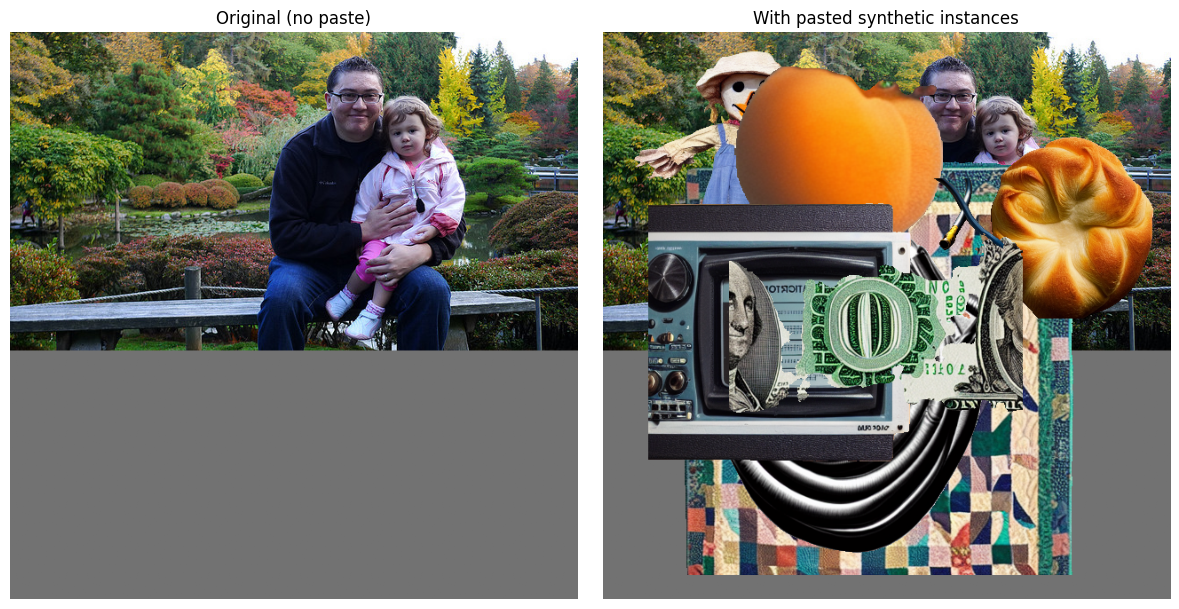

In [17]:
# Use num_workers=0 for debug to avoid multiprocessing serialization issues
triplet_batch = cfg.IMS_PER_BATCH + cfg.ACTIVE_TEST_BATCHSIZE
collator = CopyPasteCollator(
    inst_pool=inst_pool, max_samples=cfg.INST_POOL_MAX_SAMPLES,
    triplet=True, train_batch=cfg.IMS_PER_BATCH,
    test_batch=cfg.ACTIVE_TEST_BATCHSIZE, paste_prob=1.0,
)
_dbg_loader = DataLoader(
    train_dataset, batch_size=triplet_batch,
    sampler=_FiniteFromInfiniteSampler(sampler_train, num_samples=triplet_batch * 10),
    num_workers=0, collate_fn=collator, pin_memory=False,
)
_dbg_iter = iter(_dbg_loader)
_dbg_triplet = next(_dbg_iter)
del _dbg_iter, _dbg_loader, collator

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
img_paste = _dbg_triplet["paste"][0][0].permute(1, 2, 0).numpy()
img_ori = _dbg_triplet["ori"][0][0].permute(1, 2, 0).numpy()
axes[0].imshow(img_ori); axes[0].set_title("Original (no paste)"); axes[0].axis("off")
axes[1].imshow(img_paste); axes[1].set_title("With pasted synthetic instances"); axes[1].axis("off")
n_ori = len(_dbg_triplet["ori"][0][1]["labels"])
n_paste = len(_dbg_triplet["paste"][0][1]["labels"])
print(f"# instances: ori={n_ori}, paste={n_paste} (delta={n_paste - n_ori})")
plt.tight_layout(); plt.show()
del _dbg_triplet


## 18. Baseline Train


In [18]:
def run_baseline_training():
    final_path = os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_final.pth")
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[Baseline] {final_path} already exists — skipping training.")
        return final_path

    total_iters = cfg.BASELINE_ITERS or (cfg.BASELINE_EPOCHS * iters_per_epoch)
    print(f"[Baseline] total_iters = {total_iters}")

    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
    ).to(DEVICE)
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY,
    )
    scaler = torch.cuda.amp.GradScaler() if (cfg.USE_AMP and DEVICE.type == "cuda") else None

    loader = make_baseline_loader()
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)
    train_log = []

    pbar = tqdm(range(total_iters), desc="[Baseline]")
    t_start = time.time()
    for step in pbar:
        try:
            batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            batch = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.LR, cfg.WARMUP_ITERS, total_iters)
        set_lr(optimizer, lr)

        losses = train_step_baseline(
            model, optimizer, scaler, batch, DEVICE,
            use_amp=cfg.USE_AMP, clip_grad_norm=cfg.CLIP_GRAD_NORM,
        )
        logger.update(**losses, lr=lr)

        if step % cfg.LOG_EVERY == 0:
            pbar.set_postfix_str(logger.fmt(["loss_total", "lr"]))
            train_log.append({"step": step, **{k: logger.avg(k) for k in losses.keys()}, "lr": lr})

        # Per-epoch checkpoint.
        if cfg.CKPT_EVERY_EPOCH > 0 and step > 0 and (step % (iters_per_epoch * cfg.CKPT_EVERY_EPOCH) == 0):
            ck_path = os.path.join(cfg.BASELINE_CKPT_DIR, f"baseline_iter_{step}.pth")
            torch.save({"model": model.state_dict(), "step": step}, ck_path)
            print(f"\n[Baseline] checkpoint → {ck_path}")

    elapsed = time.time() - t_start
    torch.save({"model": model.state_dict(), "step": total_iters}, final_path)
    log_path = os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_training_log.json")
    with open(log_path, "w") as f:
        json.dump(train_log, f, indent=2)
    print(f"[Baseline] DONE in {elapsed/60:.1f} min — saved {final_path}")
    return final_path


baseline_ckpt_path = run_baseline_training()


[Baseline] /workspace/BSGAL-KELOMPOK-4/models/pretrained-model/baseline_final.pth already exists — skipping training.


## 19. BSGAL Train


In [19]:
def run_bsgal_training(baseline_ckpt: str):
    final_path = os.path.join(cfg.BSGAL_CKPT_DIR, "bsgal_final.pth")
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[BSGAL] {final_path} already exists — skipping training.")
        return final_path

    total_iters = cfg.BSGAL_ITERS or (cfg.BSGAL_EPOCHS * iters_per_epoch)
    print(f"[BSGAL] total_iters = {total_iters}")

    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
    ).to(DEVICE)
    print(f"[BSGAL] loading baseline weights from {baseline_ckpt}")
    state = torch.load(baseline_ckpt, map_location=DEVICE)
    model.load_state_dict(state["model"])

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY,
    )
    scaler = torch.cuda.amp.GradScaler() if (cfg.USE_AMP and DEVICE.type == "cuda") else None

    grad_dim = n_classifier_params(cfg.NUM_CLASSES + 1)
    grad_bank = GradientBank(num_params=grad_dim, momentum=cfg.ACTIVE_GRAD_MOMENTUM, device=DEVICE)

    loader = make_triplet_loader()
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)
    train_log = []
    paste_count, ori_count = 0, 0

    pbar = tqdm(range(total_iters), desc="[BSGAL]")
    t_start = time.time()
    for step in pbar:
        try:
            triplet = next(data_iter)
        except StopIteration:
            data_iter = iter(loader)
            triplet = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.LR, cfg.BSGAL_WARMUP_ITERS, total_iters)
        set_lr(optimizer, lr)

        out = train_step_bsgal(
            model, optimizer, scaler, triplet, grad_bank, DEVICE,
            decision_bias=cfg.ACTIVE_DECISION_BIAS,
            use_amp=cfg.USE_AMP, clip_grad_norm=cfg.CLIP_GRAD_NORM,
        )
        if out["use_paste"]:
            paste_count += 1
        else:
            ori_count += 1
        logger.update(
            loss_total=out["loss_total"],
            sim_paste=out["sim_paste"],
            sim_ori=out["sim_ori"],
            lr=lr,
        )

        if step % cfg.LOG_EVERY == 0:
            paste_pct = 100 * paste_count / max(1, paste_count + ori_count)
            pbar.set_postfix_str(
                f"{logger.fmt(['loss_total', 'sim_paste', 'sim_ori', 'lr'])} | paste%={paste_pct:.0f}"
            )
            train_log.append({
                "step": step,
                "loss_total": logger.avg("loss_total"),
                "sim_paste": logger.avg("sim_paste"),
                "sim_ori": logger.avg("sim_ori"),
                "paste_pct": paste_pct,
                "lr": lr,
                "use_paste": out["use_paste"],
            })

        if cfg.CKPT_EVERY_EPOCH > 0 and step > 0 and (step % (iters_per_epoch * cfg.CKPT_EVERY_EPOCH) == 0):
            ck_path = os.path.join(cfg.BSGAL_CKPT_DIR, f"bsgal_iter_{step}.pth")
            torch.save({"model": model.state_dict(), "step": step,
                        "paste_count": paste_count, "ori_count": ori_count}, ck_path)
            print(f"\n[BSGAL] checkpoint → {ck_path}")

    elapsed = time.time() - t_start
    torch.save({"model": model.state_dict(), "step": total_iters,
                "paste_count": paste_count, "ori_count": ori_count}, final_path)
    log_path = os.path.join(cfg.BSGAL_CKPT_DIR, "training_log.json")
    with open(log_path, "w") as f:
        json.dump(train_log, f, indent=2)
    print(f"[BSGAL] DONE in {elapsed/60:.1f} min — saved {final_path}")
    print(f"[BSGAL] paste chosen: {paste_count}/{paste_count + ori_count} ({100 * paste_count / max(1, paste_count + ori_count):.1f}%)")
    return final_path


if cfg.BSGAL_ENABLED:
    bsgal_ckpt_path = run_bsgal_training(baseline_ckpt_path)
else:
    print("[BSGAL] BSGAL_ENABLED=False — skipping.")
    bsgal_ckpt_path = None


[BSGAL] /workspace/BSGAL-KELOMPOK-4/models/model/bsgal_final.pth already exists — skipping training.


## 20. Final Compare


[Baseline] evaluating on 100 val images...


[eval] forward:   0%|          | 0/100 [00:00<?, ?it/s]

[eval] generated 26711 detections (boxes/masks rescaled to original image dims)
[eval] GT has 19809 images total
[diag] score distribution: min=0.0155 median=0.0397 max=0.9323 p95=0.0717
[diag] 9 unique categories predicted (top 5: [(180, 16129), (447, 8157), (864, 907), (286, 700), (440, 619)])
[diag] 6/100 images have at least one prediction whose category is in pos∪neg cat ids (98 have GT annotations)
[diag] sample pred image_id=246522: GT image size=(640, 427), pred RLE size=[640, 427]


[05/01 00:55:48] lvis.results WARNING: Assuming user provided the results in correct format.


[eval] restricting eval to 100 predicted images
[eval] raw eval_inst.results = {'AP': np.float64(0.0), 'AP50': np.float64(0.0), 'AP75': np.float64(0.0), 'APs': np.float64(0.0), 'APm': np.float64(0.0), 'APl': np.float64(0.0), 'APr': np.float64(0.0), 'APc': np.float64(0.0), 'APf': np.float64(0.0), 'AR@300': np.float64(0.0), 'ARs@300': np.float64(0.0), 'ARm@300': np.float64(0.0), 'ARl@300': np.float64(0.0)}
[eval] precision tensor shape=(10, 101, 1203, 4), filled (>-1)=522170, positive (>0)=0
[BSGAL] evaluating on 100 val images...


[eval] forward:   0%|          | 0/100 [00:00<?, ?it/s]

[eval] generated 23791 detections (boxes/masks rescaled to original image dims)
[eval] GT has 19809 images total
[diag] score distribution: min=0.0160 median=0.0648 max=0.3930 p95=0.0972
[diag] 12 unique categories predicted (top 5: [(106, 11926), (853, 7467), (1094, 2197), (897, 1713), (362, 121)])
[diag] 3/100 images have at least one prediction whose category is in pos∪neg cat ids (98 have GT annotations)
[diag] sample pred image_id=246522: GT image size=(640, 427), pred RLE size=[640, 427]


[05/01 00:58:11] lvis.results WARNING: Assuming user provided the results in correct format.


[eval] restricting eval to 100 predicted images
[eval] raw eval_inst.results = {'AP': np.float64(0.0), 'AP50': np.float64(0.0), 'AP75': np.float64(0.0), 'APs': np.float64(0.0), 'APm': np.float64(0.0), 'APl': np.float64(0.0), 'APr': np.float64(0.0), 'APc': np.float64(0.0), 'APf': np.float64(0.0), 'AR@300': np.float64(0.0), 'ARs@300': np.float64(0.0), 'ARm@300': np.float64(0.0), 'ARl@300': np.float64(0.0)}
[eval] precision tensor shape=(10, 101, 1203, 4), filled (>-1)=522170, positive (>0)=0

Metric       Baseline        BSGAL          Δ
--------------------------------------------------------------------------------
AP              0.000        0.000     +0.000
AP50            0.000        0.000     +0.000
AP75            0.000        0.000     +0.000
APs             0.000        0.000     +0.000
APm             0.000        0.000     +0.000
APl             0.000        0.000     +0.000
APr             0.000        0.000     +0.000
APc             0.000        0.000     +0.000
APf      

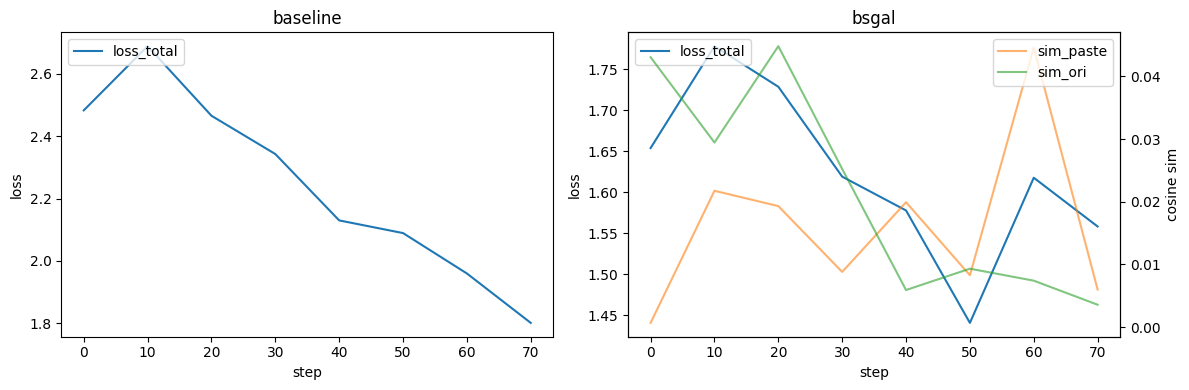

In [20]:
def evaluate_checkpoint(ckpt_path: str, eval_loader: DataLoader, label: str) -> Dict[str, float]:
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"[{label}] checkpoint not found: {ckpt_path}")
        return {}
    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
    ).to(DEVICE)
    state = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(state["model"])
    print(f"[{label}] evaluating on {len(val_records)} val images...")
    metrics = evaluate_on_lvis(model, eval_loader, cfg.VAL_ANN_JSON, DEVICE)
    del model
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    return metrics


eval_loader = make_eval_loader()
metrics_baseline = evaluate_checkpoint(baseline_ckpt_path, eval_loader, "Baseline")
metrics_bsgal = evaluate_checkpoint(bsgal_ckpt_path, eval_loader, "BSGAL") if bsgal_ckpt_path else {}

# Table
keys = ["AP", "AP50", "AP75", "APs", "APm", "APl", "APr", "APc", "APf"]
print("\n" + "=" * 80)
print(f"{'Metric':<8} {'Baseline':>12} {'BSGAL':>12} {'Δ':>10}")
print("-" * 80)
for k in keys:
    b = metrics_baseline.get(k, 0.0)
    g = metrics_bsgal.get(k, 0.0) if metrics_bsgal else 0.0
    delta = g - b
    print(f"{k:<8} {b:>12.3f} {g:>12.3f} {delta:>+10.3f}")
print("=" * 80)

# Plot
log_paths = []
bp = os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_training_log.json")
gp = os.path.join(cfg.BSGAL_CKPT_DIR, "training_log.json")
if os.path.exists(bp): log_paths.append(("baseline", bp))
if os.path.exists(gp): log_paths.append(("bsgal", gp))

if log_paths:
    fig, axes = plt.subplots(1, len(log_paths), figsize=(6 * len(log_paths), 4), squeeze=False)
    for ax, (name, path) in zip(axes[0], log_paths):
        with open(path) as f:
            log = json.load(f)
        steps = [e["step"] for e in log]
        loss = [e.get("loss_total", 0.0) for e in log]
        ax.plot(steps, loss, label="loss_total")
        if name == "bsgal":
            sp = [e.get("sim_paste", 0.0) for e in log]
            so = [e.get("sim_ori", 0.0) for e in log]
            ax2 = ax.twinx()
            ax2.plot(steps, sp, color="tab:orange", alpha=0.6, label="sim_paste")
            ax2.plot(steps, so, color="tab:green", alpha=0.6, label="sim_ori")
            ax2.set_ylabel("cosine sim")
            ax2.legend(loc="upper right")
        ax.set_title(name)
        ax.set_xlabel("step"); ax.set_ylabel("loss")
        ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()
